# Importation des données

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 500)
import numpy as np
import matplotlib.pyplot as plt

import requests
from bs4 import BeautifulSoup
import os
import s3fs
import ast
import json


from sklearn.linear_model import RidgeCV, ElasticNetCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score,root_mean_squared_error

import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
from sklearn.metrics import r2_score

In [2]:
X_train = pd.read_csv(r'C:\Users\marie\Documents\Python\formation_cepe\Projet\data_projet\X_train.csv')
y_train = pd.read_csv(r'C:\Users\marie\Documents\Python\formation_cepe\Projet\data_projet\y_train.csv')
X_test = pd.read_csv(r'C:\Users\marie\Documents\Python\formation_cepe\Projet\data_projet\X_test.csv')
y_test = pd.read_csv(r'C:\Users\marie\Documents\Python\formation_cepe\Projet\data_projet\y_test.csv')
weights_train = pd.read_csv(r'C:\Users\marie\Documents\Python\formation_cepe\Projet\data_projet\weights_train.csv')
weights_test = pd.read_csv(r'C:\Users\marie\Documents\Python\formation_cepe\Projet\data_projet\weights_test.csv')

In [3]:
X_train=X_train.iloc[:,1:]
X_test=X_test.iloc[:,1:]
y_train=np.array(y_train)[:, 0]
y_test=np.array(y_test)[:, 0]
weights_train=np.log1p(np.array(weights_train)[:, 0])
weights_test=np.log1p(np.array(weights_test)[:, 0])
y_train_log=np.log1p(y_train)
y_test_log=np.log1p(y_test)

In [4]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),         # transforme les données
    columns=X_train.columns,               # garde les mêmes noms de colonnes
    index=X_train.index                    # garde les mêmes index
)
X_test_scaled = pd.DataFrame(
    scaler.fit_transform(X_test),         # transforme les données
    columns=X_test.columns,               # garde les mêmes noms de colonnes
    index=X_test.index                    # garde les mêmes index
)

In [9]:
print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (27567, 47)
Dimensions de X_test  : (3063, 47)
Dimensions de y_train : (27567,)
Dimensions de y_test  : (3063,)


In [36]:
y_train_2=y_train**2
y_test_2=y_test**2

                              runtime  indic_collec      rang     vote_prec  \
runtime                      1.000000     -0.020174 -0.034273 -2.556440e-02   
indic_collec                -0.020174      1.000000  0.760765  7.872115e-01   
rang                        -0.034273      0.760765  1.000000  7.628727e-01   
vote_prec                   -0.025564      0.787212  0.762873  1.000000e+00   
release_year                 0.083045      0.005845 -0.015775  1.379931e-02   
North_America               -0.012921      0.067192  0.029291  4.166699e-02   
Europe                       0.066268     -0.045903 -0.025604 -3.311976e-02   
Asia                         0.112396      0.037315  0.044450  3.835876e-02   
Latin_America                0.000318     -0.037160 -0.031802 -3.175393e-02   
Oceania                      0.006985     -0.007364 -0.010933 -4.160969e-03   
Africa                       0.012951     -0.002840 -0.004547  4.750606e-07   
Drama                        0.220316     -0.181295 

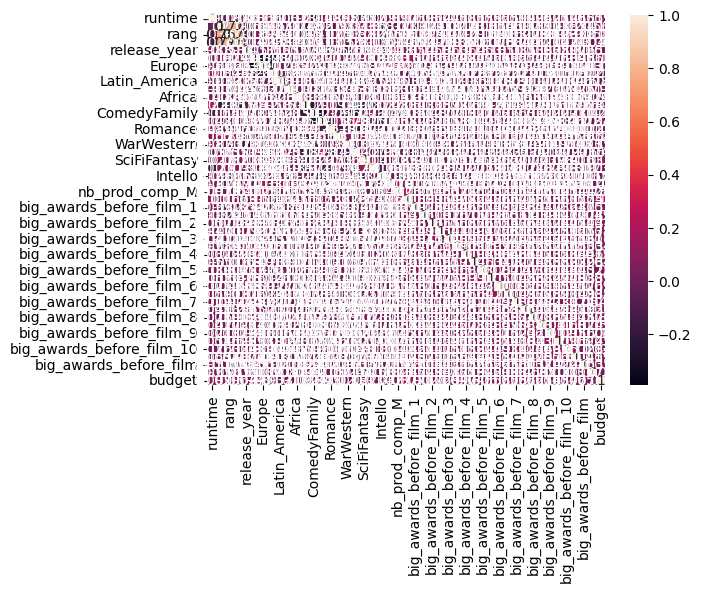

In [ ]:
import pandas as pd

corr = X_train.corr()
print(corr)
import seaborn as sns



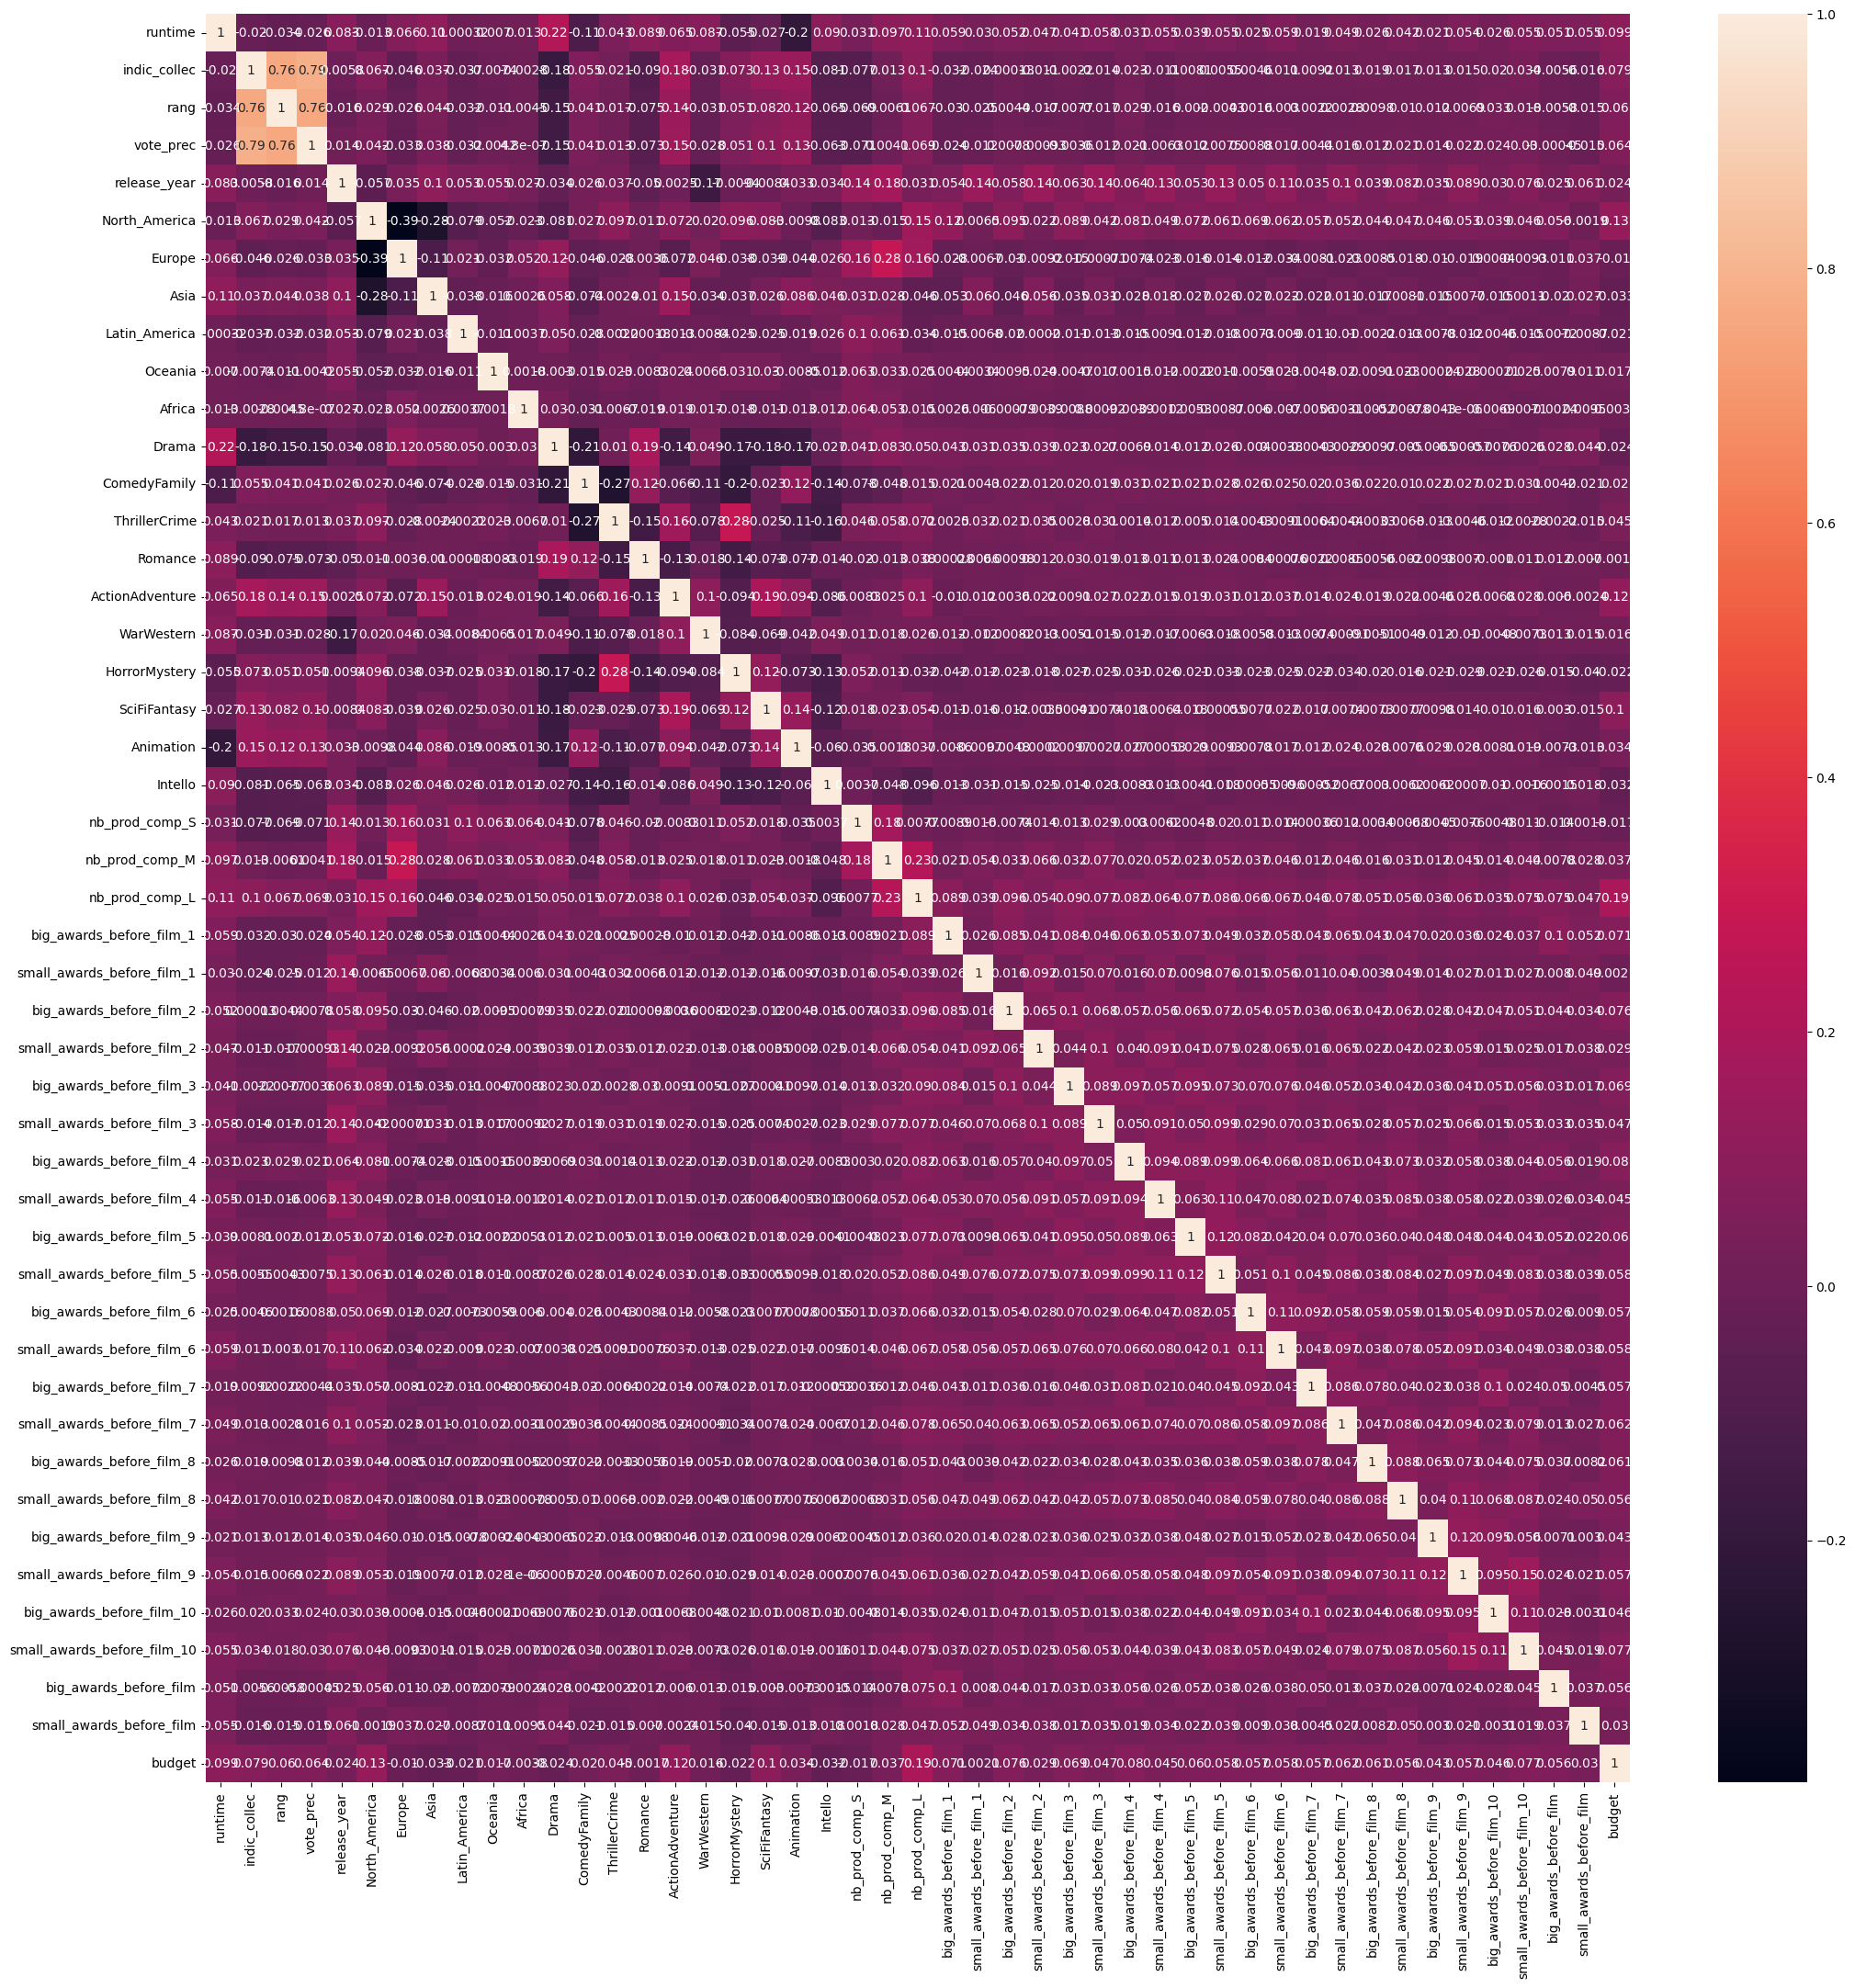

In [157]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 25))
sns.heatmap(X_train.corr(), annot=True)
plt.show()

# Régression linéaire

In [115]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_log, sample_weight=weights_train)
y_predict = lr.predict(X_test_scaled)

In [116]:
print('RMSE : ',root_mean_squared_error(y_test_log, y_predict, sample_weight=weights_test))
print('MAE : ',mean_absolute_error(y_test_log, y_predict, sample_weight=weights_test))
print('R2 : ', r2_score(y_test_log, y_predict, sample_weight=weights_test))

RMSE :  0.14656076494325135
MAE :  0.10725990647433467
R2 :  0.18406092281780317


In [117]:
print('RMSE : ',root_mean_squared_error(y_test_log, y_predict))
print('MAE : ',mean_absolute_error(y_test_log, y_predict))
print('R2 : ', r2_score(y_test_log, y_predict))

RMSE :  0.16202733869803584
MAE :  0.116022679021456
R2 :  0.14881648658475422


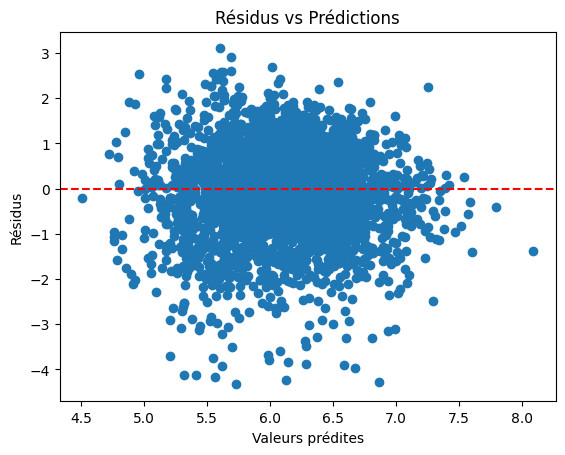

In [44]:
residuals = y_test - y_predict
plt.scatter(y_predict, residuals)
plt.axhline(0, color='red', linestyle='--')  # ligne zéro
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs Prédictions")
plt.show()

In [55]:
X_test

,runtime,indic_collec,rang,vote_prec,release_year,North_America,Europe,Asia,Latin_America,Oceania,...,small_awards_before_film_7,big_awards_before_film_8,small_awards_before_film_8,big_awards_before_film_9,small_awards_before_film_9,big_awards_before_film_10,small_awards_before_film_10,big_awards_before_film,small_awards_before_film,budget
0,103.0,0,-1.0,-1.0,1953,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
1,92.0,1,2.0,8.3,2002,0,2,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,-1.0
2,98.0,0,-1.0,-1.0,2014,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
3,84.0,0,-1.0,-1.0,2015,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
4,120.0,0,-1.0,-1.0,2008,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2276979.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3058,86.0,0,-1.0,-1.0,2010,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6745.0
3059,88.0,0,-1.0,-1.0,2001,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
3060,140.0,0,-1.0,-1.0,1982,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
3061,85.0,0,-1.0,-1.0,2015,1,0,0,0,0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0


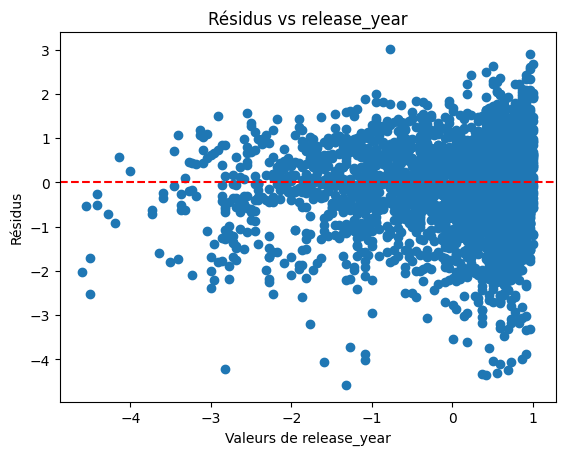

In [131]:
plt.scatter(X_test_scaled["release_year"], residuals)
plt.axhline(0, color='red', linestyle='--')  # ligne zéro
plt.xlabel("Valeurs de release_year")
plt.ylabel("Résidus")
plt.title("Résidus vs release_year")
plt.show()

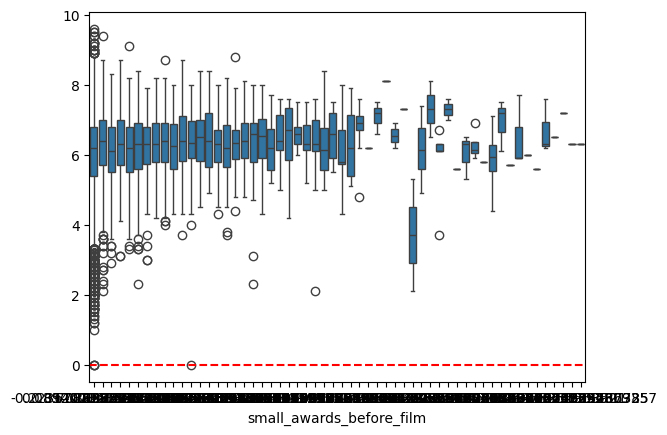

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=X_train_scaled["small_awards_before_film"], y=y_train)
plt.axhline(0, color='red', linestyle='--')
plt.show()


In [104]:
X_train_log = X_train.copy()
X_train_log["runtime"] = np.log1p(X_train_log["runtime"]+1)
X_train_log["budget"] = np.log1p(X_train_log["budget"]+2)
X_train_log["release_year"] = np.log1p(X_train_log["release_year"])

In [105]:
X_test_log = X_test.copy()
X_test_log["runtime"] = np.log1p(X_test_log["runtime"]+1)
X_test_log["budget"] = np.log1p(X_test_log["budget"]+2)
X_test_log["release_year"] = np.log1p(X_test_log["release_year"])

In [106]:
scaler = StandardScaler()
X_train_log_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_log),         # transforme les données
    columns=X_train_log.columns,               # garde les mêmes noms de colonnes
    index=X_train_log.index                    # garde les mêmes index
)
X_test_log_scaled = pd.DataFrame(
    scaler.fit_transform(X_test_log),         # transforme les données
    columns=X_test_log.columns,               # garde les mêmes noms de colonnes
    index=X_test_log.index                    # garde les mêmes index
)

In [107]:
lr = LinearRegression()
lr.fit(X_train_log_scaled, y_train, sample_weight=weights_train)
y_predict = lr.predict(X_test_log_scaled)

In [108]:
print('RMSE : ',root_mean_squared_error(y_test, y_predict))
print('MAE : ',mean_absolute_error(y_test, y_predict))
print('R2 : ', r2_score(y_test, y_predict))

RMSE :  1.028405308292759
MAE :  0.7866010153454114
R2 :  0.1471470957218185


In [109]:
print('RMSE : ',root_mean_squared_error(y_test, y_predict, sample_weight=weights_test))
print('MAE : ',mean_absolute_error(y_test, y_predict, sample_weight=weights_test))
print('R2 : ', r2_score(y_test, y_predict, sample_weight=weights_test))

RMSE :  0.9562740485672303
MAE :  0.7376658271996612
R2 :  0.17964901699691083


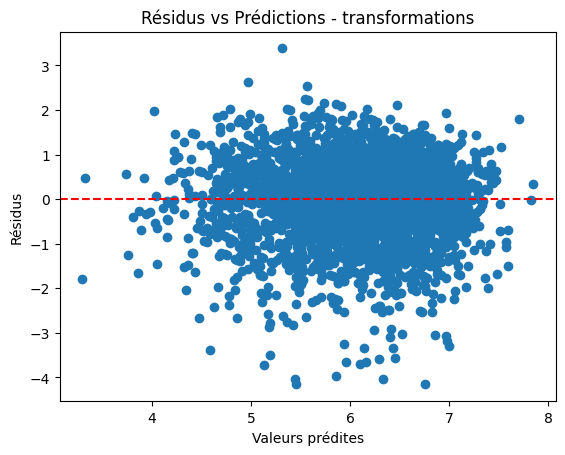

In [132]:
residuals = y_test - y_predict
plt.scatter(y_predict, residuals)
plt.axhline(0, color='red', linestyle='--')  # ligne zéro
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs Prédictions - transformations")
plt.show()

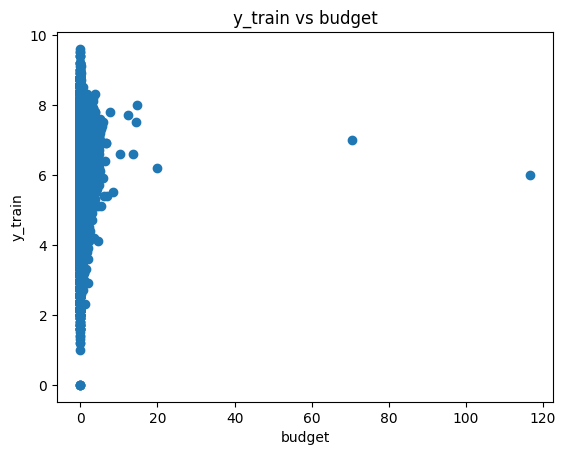

In [145]:
plt.scatter(X_train_scaled["budget"], y_train)
plt.xlabel("budget")
plt.ylabel("y_train")
plt.title("y_train vs budget")
plt.show()

# Random Forest

## Random Forest simple

In [5]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_predict = rf.predict(X_test)

In [7]:
print('RMSE : ',root_mean_squared_error(y_test, y_predict, sample_weight=weights_test))
print('MAE : ',mean_absolute_error(y_test, y_predict, sample_weight=weights_test))
print('R2 : ', r2_score(y_test, y_predict, sample_weight=weights_test))

RMSE :  0.88827669435149
MAE :  0.6882830812264996
R2 :  0.2921658719586886


In [6]:
print('RMSE : ',root_mean_squared_error(y_test, y_predict))
print('MAE : ',mean_absolute_error(y_test, y_predict))
print('R2 : ', r2_score(y_test, y_predict))

RMSE :  0.9374464148972443
MAE :  0.7198771367421711
R2 :  0.29133918646671586


## Tuning Random Forest

In [21]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 500, 1000],
    'max_depth': [None, 10, 20, 50, 100],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                     # cross-validation 5 folds
    scoring='r2',  # pour régression
    n_jobs=-1                  # paralléliser
)

grid_search.fit(X_train_scaled, y_train, sample_weight=weights_train)

# Meilleur modèle
best_model = grid_search.best_estimator_
print("Meilleurs paramètres :",grid_search.best_params_)

# RMSE moyen sur CV
best_r2 = grid_search.best_score_   # MSE est retourné négatif par scikit-learn
print("Meilleur RMSE (CV) :", best_r2)

# RMSE sur le test set
y_pred = best_model.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred, sample_weight=weights_test))
print("RMSE sur test set :", test_rmse)

test_mae = mean_absolute_error(y_test, y_pred, sample_weight=weights_test)
print("MAE sur test set :", test_mae)

test_r2 = r2_score(y_test, y_pred, sample_weight=weights_test)
print("R2 sur test set :", test_r2)

/opt/python/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Meilleurs paramètres : {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 1000}
Meilleur RMSE (CV) : 0.35693308277160485
RMSE sur test set : 0.8509309913263101
MAE sur test set : 0.6571852094617182
R2 sur test set : 0.35043346094151284


Meilleurs paramètres : {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 1000}

In [123]:
rf = RandomForestRegressor(random_state=42, n_estimators=1000, max_depth=50, max_features='sqrt', min_samples_leaf=2, min_samples_split=2)
rf.fit(X_train, y_train, sample_weight=weights_train)
y_predict = rf.predict(X_test)

In [124]:
print('RMSE : ',root_mean_squared_error(y_test, y_predict, sample_weight=weights_test))
print('MAE : ',mean_absolute_error(y_test, y_predict, sample_weight=weights_test))
print('R2 : ', r2_score(y_test, y_predict, sample_weight=weights_test))

RMSE :  0.8521188235683891
MAE :  0.6596958231968687
R2 :  0.3486187083566963


In [125]:
print('RMSE : ',root_mean_squared_error(y_test, y_predict))
print('MAE : ',mean_absolute_error(y_test, y_predict))
print('R2 : ', r2_score(y_test, y_predict))

RMSE :  0.9079985235099308
MAE :  0.6953883359718158
R2 :  0.33516205560271184


In [27]:
test_rmse_p = root_mean_squared_error(y_test, y_pred, sample_weight=weights_test)
test_mae_p = mean_absolute_error(y_test, y_pred, sample_weight=weights_test)
test_r2_p = r2_score(y_test, y_pred, sample_weight=weights_test)
test_rmse = root_mean_squared_error(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

In [36]:

resultats = {
    'Métrique': ['RMSE_pondere', 'MAE_pondere', 'R2_pondere', 'RMSE', 'MAE', 'R2'],
    'Random Forest': [test_rmse_p,test_mae_p, test_r2_p, test_rmse, test_mae, test_r2]
}

resultats = pd.DataFrame(resultats)
print(resultats)


       Métrique  Random Forest
0  RMSE_pondere       0.850931
1   MAE_pondere       0.657185
2    R2_pondere       0.350433
3          RMSE       0.910312
4           MAE       0.695215
5            R2       0.331770


Meilleurs paramètres : {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 1000}
Meilleur RMSE (CV) : 0.35693308277160485
RMSE sur test set : 0.8509309913263101
MAE sur test set : 0.6571852094617182
R2 sur test set : 0.35043346094151284

# Boosting

## GradientBoosting simple

In [18]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train_scaled, y_train, sample_weight=weights_train)
y_predict = gb.predict(X_test_scaled)

In [19]:
print('RMSE : ',root_mean_squared_error(y_test, y_predict, sample_weight=weights_test))
print('MAE : ',mean_absolute_error(y_test, y_predict, sample_weight=weights_test))
print('R2 : ', r2_score(y_test, y_predict, sample_weight=weights_test))

RMSE :  0.8699405993037529
MAE :  0.671747536015982
R2 :  0.32108694229878987


## Tuning Boosting

In [37]:
gb = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [200, 500,1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_samples_leaf': [1, 3],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,                     # cross-validation 5 folds
    scoring='r2',  # pour régression
    n_jobs=-1                  # paralléliser
)

grid_search.fit(X_train_scaled, y_train, sample_weight=weights_train)

# Meilleur modèle
best_model = grid_search.best_estimator_
print("Meilleurs paramètres :",grid_search.best_params_)

# RMSE moyen sur CV
best_r2 = grid_search.best_score_   # MSE est retourné négatif par scikit-learn
print("Meilleur RMSE (CV) :", best_r2)

# RMSE sur le test set
y_pred = best_model.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred, sample_weight=weights_test))
print("RMSE sur test set :", test_rmse)

test_mae = mean_absolute_error(y_test, y_pred, sample_weight=weights_test)
print("MAE sur test set :", test_mae)

test_r2 = r2_score(y_test, y_pred, sample_weight=weights_test)
print("R2 sur test set :", test_r2)

Meilleurs paramètres : {'learning_rate': 0.01, 'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 1000, 'subsample': 0.8}
Meilleur RMSE (CV) : 0.37356534307164657
RMSE sur test set : 0.8466398164409417
MAE sur test set : 0.6528103228355736
R2 sur test set : 0.3569683628870751


In [ ]:
gb = GradientBoostingRegressor(random_state=42, n_estimators=1000, subsample=0.8, min_samples_leaf=3, max_depth=10, learning_rate=0.01)
gb.fit(X_train, y_train, sample_weight=weights_train)
y_predict = gb.predict(X_test)

In [127]:
print('RMSE : ',root_mean_squared_error(y_test, y_predict, sample_weight=weights_test))
print('MAE : ',mean_absolute_error(y_test, y_predict, sample_weight=weights_test))
print('R2 : ', r2_score(y_test, y_predict, sample_weight=weights_test))

RMSE :  0.8436982559685089
MAE :  0.6523908736505681
R2 :  0.36142889137320855


In [128]:
print('RMSE : ',root_mean_squared_error(y_test, y_predict))
print('MAE : ',mean_absolute_error(y_test, y_predict))
print('R2 : ', r2_score(y_test, y_predict))

RMSE :  0.8977780352290679
MAE :  0.687832830385685
R2 :  0.3500447364645646


{'learning_rate': 0.01, 'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 1000, 'subsample': 0.8}

In [38]:
test_rmse_p = root_mean_squared_error(y_test, y_pred, sample_weight=weights_test)
test_mae_p = mean_absolute_error(y_test, y_pred, sample_weight=weights_test)
test_r2_p = r2_score(y_test, y_pred, sample_weight=weights_test)
test_rmse = root_mean_squared_error(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

In [44]:
resultats_2 = {
    'Gradient Boosting': [test_rmse_p,test_mae_p, test_r2_p, test_rmse, test_mae, test_r2]
}

resultats_2 = pd.DataFrame(resultats_2)
resultats = pd.concat([resultats, resultats_2], axis=1)

resultats=resultats.iloc[:,0:4]

In [51]:
resultats

,Métrique,Random Forest,Métrique,Gradient Boosting
0,RMSE_pondere,0.850931,RMSE_pondere,0.846640
1,MAE_pondere,0.657185,MAE_pondere,0.652810
2,R2_pondere,0.350433,R2_pondere,0.356968
3,RMSE,0.910312,RMSE,0.904615
4,MAE,0.695215,MAE,0.690999
5,R2,0.331770,R2,0.340107


# Réseau de neurones

## Réseau de neurones simple

In [133]:


# Modèle simple
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)  # sortie continue
])

model.compile(optimizer="adam", loss="mae")

# Callback pour R2
class R2Callback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(X_test, verbose=0)
        r2 = r2_score(y_test, y_pred)
        print(f" - val_R2: {r2:.4f}")

# Entraînement
history = model.fit(
    X_train_scaled, y_train, sample_weight=weights_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50
)

# RMSE sur le test
y_pred = model.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE sur test set :", test_rmse)

test_mae = mean_absolute_error(y_test, y_pred)
print("MAE sur test set :", test_mae)

test_r2 = r2_score(y_test, y_pred)
print("R2 sur test set :", test_r2)


Epoch 1/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3.6669 - val_loss: 0.8139
Epoch 2/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.5217 - val_loss: 0.8491
Epoch 3/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.4063 - val_loss: 0.7742
Epoch 4/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.3371 - val_loss: 0.7764
Epoch 5/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.3098 - val_loss: 0.7563
Epoch 6/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.2787 - val_loss: 0.7802
Epoch 7/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.2562 - val_loss: 0.7394
Epoch 8/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.2311 - val_loss: 0.7590
Epoch 9/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.2212 - val_loss: 0.7670
Epoch 10/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.1961 - val_loss: 0.7335
Epoch 11/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.1885 - val_loss: 0.7444
Epoch 12/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

In [23]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler

# --------------------------
# Fonction pour construire le modèle
# --------------------------
def build_model(input_shape):
    inputs = keras.Input(shape=(input_shape,))
    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(1)(x)
    return keras.Model(inputs, outputs)

# --------------------------
# R² personnalisé
# --------------------------
def r2_keras(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - ss_res/(ss_tot + tf.keras.backend.epsilon())

# --------------------------
# K-Fold Cross Validation
# --------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_r2_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
    print(f"\n--- Fold {fold+1} ---")
    
    X_train_nn, X_val_nn = X_train_scaled.iloc[train_idx,:], X_train_scaled.iloc[val_idx,:]
    y_train_nn, y_val_nn = y_train[train_idx], y_train[val_idx]
    sw_train, sw_val = weights_train[train_idx], weights_train[val_idx]
    
    model = build_model(X_train_nn.shape[1])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="mse",
        metrics=[r2_keras]
    )
    
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
    ]
    
    history = model.fit(
        X_train_nn, y_train_nn,
        validation_data=(X_val_nn, y_val_nn, sw_val),
        sample_weight=sw_train,
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=0
    )
    
    val_loss, val_r2 = model.evaluate(X_val_nn, y_val_nn, sample_weight=sw_val, verbose=0)
    print(f"Validation R² fold {fold+1}: {val_r2:.4f}")
    val_r2_scores.append(val_r2)

print(f"\nMean Validation R² across folds: {np.mean(val_r2_scores):.4f}")

# --------------------------
# Évaluation finale sur le test set
# --------------------------
model = build_model(X_test_scaled.shape[1])
model.compile(optimizer="adam", loss="mse", metrics=[r2_keras])
model.fit(X_train_scaled, y_train, sample_weight=weights_train, epochs=100, batch_size=32, verbose=0)
test_loss, test_r2 = model.evaluate(X_test_scaled, y_test, sample_weight=weights_test)
print(f"\nTest R²: {test_r2:.4f}")



--- Fold 1 ---
Validation R² fold 1: -45.1912

--- Fold 2 ---
Validation R² fold 2: -44.5244

--- Fold 3 ---
Validation R² fold 3: -43.4129

--- Fold 4 ---
Validation R² fold 4: -44.4437

--- Fold 5 ---
Validation R² fold 5: -45.3742

Mean Validation R² across folds: -44.5893
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.0962 - r2_keras: -46.3342

Test R²: -46.3342


In [20]:
X_train_scaled.iloc[train_idx,:]

,runtime,indic_collec,rang,vote_prec,release_year,North_America,Europe,Asia,Latin_America,Oceania,...,small_awards_before_film_7,big_awards_before_film_8,small_awards_before_film_8,big_awards_before_film_9,small_awards_before_film_9,big_awards_before_film_10,small_awards_before_film_10,big_awards_before_film,small_awards_before_film,budget
0,0.571579,-0.372689,-0.283529,-0.293385,0.564915,-1.071222,0.705865,-0.339049,-0.143946,-0.133606,...,-0.178541,-0.075908,-0.147600,-0.064849,-0.149234,-0.062475,-0.142181,-0.089049,-0.223678,-0.062274
1,-0.294645,-0.372689,-0.283529,-0.293385,0.074543,-1.071222,-0.590510,-0.339049,5.805336,-0.133606,...,-0.178541,-0.075908,-0.147600,-0.064849,-0.149234,-0.062475,-0.142181,-0.089049,-0.223678,-0.212160
2,-0.406416,-0.372689,-0.283529,-0.293385,0.787812,-1.071222,0.705865,-0.339049,-0.143946,-0.133606,...,-0.178541,-0.075908,-0.147600,-0.064849,-0.149234,-0.062475,-0.142181,-0.089049,0.085200,-0.212160
4,-2.390348,-0.372689,-0.283529,-0.293385,0.609495,-1.071222,-0.590510,-0.339049,-0.143946,-0.133606,...,-0.178541,-0.075908,-0.147600,-0.064849,-0.149234,-0.062475,-0.142181,-0.089049,-0.223678,-0.212160
5,-0.238759,-0.372689,-0.283529,-0.293385,0.921550,-1.071222,0.705865,-0.339049,-0.143946,-0.133606,...,-0.178541,-0.075908,-0.147600,-0.064849,-0.149234,-0.062475,-0.142181,-0.089049,-0.223678,-0.212160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27561,0.180381,-0.372689,-0.283529,-0.293385,0.386598,-1.071222,3.298616,2.400274,-0.143946,-0.133606,...,-0.178541,-0.075908,-0.147600,-0.064849,-0.149234,-0.062475,-0.142181,-0.089049,-0.223678,-0.212160
27562,0.320095,-0.372689,-0.283529,-0.293385,0.698653,-1.071222,0.705865,-0.339049,-0.143946,-0.133606,...,-0.178541,-0.075908,-0.147600,-0.064849,-0.149234,-0.062475,-0.142181,-0.089049,-0.223678,-0.212160
27563,0.320095,-0.372689,-0.283529,-0.293385,0.966129,0.813896,-0.590510,-0.339049,-0.143946,-0.133606,...,-0.178541,-0.075908,-0.147600,-0.064849,-0.149234,-0.062475,-0.142181,-0.089049,-0.223678,-0.212160
27565,0.739236,-0.372689,-0.283529,-0.293385,0.921550,-1.071222,3.298616,-0.339049,-0.143946,-0.133606,...,-0.178541,-0.075908,0.316725,-0.064849,-0.149234,-0.062475,-0.142181,-0.089049,-0.223678,0.029908


In [17]:
train_idx

array([    0,     1,     2, ..., 27563, 27565, 27566], shape=(22053,))

In [18]:
val_idx

array([    3,     6,    17, ..., 27553, 27557, 27564], shape=(5514,))

## Permutation importance

In [ ]:
from sklearn.inspection import permutation_importance

model = GradientBoostingRegressor(random_state=42, learning_rate= 0.01, max_depth= 10, min_samples_leaf= 3, n_estimators= 1000, subsample= 0.8)
model.fit(X_train, y_train, sample_weight=weights_train)

perm = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=42)
importances = pd.Series(perm.importances_mean, index=X_train.columns)
ranking = importances.sort_values(ascending=False)



KeyboardInterrupt: 

In [160]:
ranking

runtime                        0.314966
release_year                   0.246484
Intello                        0.108409
Drama                          0.101760
budget                         0.077594
HorrorMystery                  0.069900
nb_prod_comp_L                 0.062275
North_America                  0.053214
Animation                      0.044199
ActionAdventure                0.042999
nb_prod_comp_M                 0.035086
vote_prec                      0.035033
ComedyFamily                   0.034025
Asia                           0.033819
SciFiFantasy                   0.028951
Europe                         0.028619
rang                           0.026135
nb_prod_comp_S                 0.021173
ThrillerCrime                  0.020750
Romance                        0.020088
small_awards_before_film_1     0.019032
small_awards_before_film       0.015052
small_awards_before_film_2     0.013714
small_awards_before_film_3     0.011753
big_awards_before_film_1       0.010232


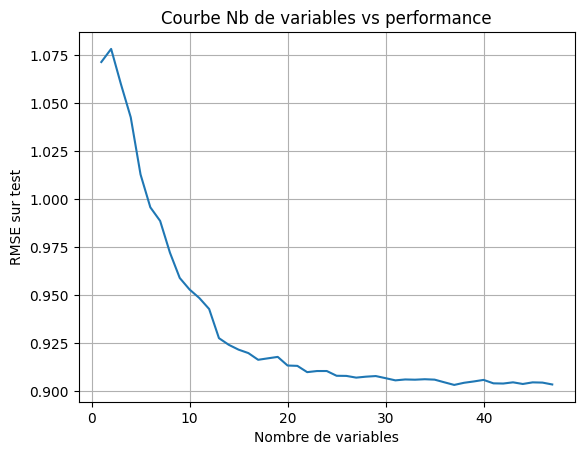

In [11]:
scores = []
features_ordered = ranking.index.tolist()

for k in range(1, len(features_ordered)+1):
    selected_features = features_ordered[:k]
    
    # Subset des données
    X_train_k = X_train_scaled[selected_features]
    X_test_k  = X_test_scaled[selected_features]
    
    # Entraîner un nouveau modèle
    model_k = model.__class__(**model.get_params())  # clone du modèle
    model_k.fit(X_train_k, y_train, sample_weight=weights_train)
    
    # Performance
    y_pred = model_k.predict(X_test_k)
    score = root_mean_squared_error(y_test, y_pred)
    
    scores.append(score)

import matplotlib.pyplot as plt

plt.plot(range(1, len(scores)+1), scores)
plt.xlabel("Nombre de variables")
plt.ylabel("RMSE sur test")
plt.title("Courbe Nb de variables vs performance")
plt.grid(True)
plt.show()


In [ ]:
index_min = scores.index(min(scores))
index_min

ranking=pd.DataFrame(ranking)
ranking['variable'] = ranking.index
selection_variables = list(ranking.iloc[index_min:,:].variable)